# Metamodele PCE creux — MAELIA

Ce notebook entraine des **polynomes du chaos creux** avec OpenTURNS pour predire les trois sorties de MAELIA :

| Sortie | Description | Unite |
|--------|-------------|-------|
| `N_lixi` | N lixivie | kgN/ha |
| `dCorg` | Variation de C organique | kgC/ha |
| `rdt` | Rendement ble d'hiver | t/ha |

**Entrees (30 dimensions)** : 26 variables du plan SMT + 2 indicatrices de zone (beauce/oceanique) + 2 indicatrices de type de sol (A/B ; C = reference).

**Strategie PCE** : base de Legendre, selection adaptative (CleaningStrategy) des termes les plus energetiques + regression OLS.

**Validation** : k-fold **stratifie par simulation** — chaque fold retire 20 % des simulations entieres, evitant la fuite d'information.

**Prerequis** : avoir execute les cellules de la section 5 de `batch_simulations_smt.ipynb` pour generer `doe_xt.npy`, `doe_is_acting.npy` et `dataset_metamodel.csv` dans `/tmp/maelia_smt_xml/`.


## 0. Imports & configuration

In [17]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openturns as ot
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'savefig.bbox': 'tight'})
ot.Log.Show(ot.Log.NONE)

# ─── Chemins ────────────────────────────────────────────────────────────────
XML_DIR = Path('/tmp/maelia_smt_xml')
OUT_DIR = XML_DIR

# ─── Parametres PCE ─────────────────────────────────────────────────────────
PCE_DEGREE  = 1     # degre 1 : stable avec 100 configs SMT uniques
N_MAX_TERMS = 31    # termes max (= 1 + 30 variables pour degree 1)
N_FOLDS_CV  = 5     # folds pour le Q2 stratifie
RANDOM_SEED = 42

# ─── Labels ─────────────────────────────────────────────────────────────────
OUTPUT_COLS   = ['N_lixi', 'dCorg', 'rdt']
OUTPUT_LABELS = ['N lixivie (kgN/ha)', 'dC organique (kgC/ha)', 'Rendement (t/ha)']
OUTPUT_COLORS = ['#e74c3c', '#3498db', '#2ecc71']

SOL_TYPES  = ['18960_27491', '330104_330367_1', '330151_330489_1']  # A, B, C
SOL_LABELS = ['Sol A (18960_27491)', 'Sol B (330104_330367_1)', 'Sol C (330151_330489_1)']

ZONE_MAP   = {'beauce': 0, 'oceanique': 1, 'sudouest': 2}
ZONE_NAMES = {0: 'beauce', 1: 'oceanique', 2: 'sudouest'}

print(f'OpenTURNS : {ot.__version__}')
print(f'Degre PCE : {PCE_DEGREE}  |  Max termes : {N_MAX_TERMS}  |  CV : {N_FOLDS_CV}-fold stratifie')


OpenTURNS : 1.26
Degre PCE : 1  |  Max termes : 31  |  CV : 5-fold stratifie


## 1. Chargement des donnees

In [18]:
xt          = np.load(XML_DIR / 'doe_xt.npy')          # (N_DOE, 26)
is_acting_t = np.load(XML_DIR / 'doe_is_acting.npy')   # (N_DOE, 26)
N_DOE, N_SMT_VARS = xt.shape
print(f'DOE : {N_DOE} simulations x {N_SMT_VARS} variables SMT')

df_mm = pd.read_csv(XML_DIR / 'dataset_metamodel.csv')
print(f'Dataset : {len(df_mm)} lignes  ({df_mm["sim_idx"].nunique()} sim x {df_mm["ilot_id"].nunique()} parcelles)')
print()
print('Distribution (zone, sol_type, zone_meteo) :')
print(df_mm.groupby(['zone', 'sol_type', 'zone_meteo']).size().reset_index(name='n_rows').to_string(index=False))


DOE : 100 simulations x 26 variables SMT
Dataset : 13000 lignes  (100 sim x 130 parcelles)

Distribution (zone, sol_type, zone_meteo) :
     zone        sol_type  zone_meteo  n_rows
   beauce     18960_27491       13218    1600
   beauce 330104_330367_1       13218    1800
   beauce 330151_330489_1       13218    1700
oceanique     18960_27491       13761     900
oceanique 330104_330367_1       13761     900
oceanique 330151_330489_1       13218     100
oceanique 330151_330489_1       13761     800
 sudouest     18960_27491        4756    1700
 sudouest 330104_330367_1        4756    1700
 sudouest 330151_330489_1        4756    1800


## 2. Construction des matrices X et Y

**Encodage zone** (= climat) : 2 indicatrices (beauce / oceanique ; sudouest = reference).  
**Encodage sol** : 2 indicatrices (sol A / sol B ; sol C = reference).  
Le sol varie au sein de chaque zone climatique -> effets identifiables separement.


In [19]:
INPUT_LABELS = [
    'Nb apports fertilisation',     # 0  ordinal  {0,1,2,3}
    'Preparation sol (oui/non)',    # 1  binaire  {0,1}
    'Nb operations prepa sol',      # 2  ordinal  {0,1}
    'Type prepa sol 1',             # 3  categ.   {0-3}
    'Type prepa sol 2',             # 4  categ.   {0-3}
    'Nb produits engrais F1',       # 5  ordinal  {0,1}
    'Type engrais F1-1',            # 6  categ.   {0-3}
    'Type engrais F1-2',            # 7  categ.   {0-3}
    'Nb produits engrais F2',       # 8  ordinal  {0,1}
    'Type engrais F2-1',            # 9  categ.   {0-3}
    'Type engrais F2-2',            # 10 categ.   {0-3}
    'Nb produits engrais F3',       # 11 ordinal  {0,1}
    'Type engrais F3-1',            # 12 categ.   {0-3}
    'Type engrais F3-2',            # 13 categ.   {0-3}
    'Jour de semis (j/an)',         # 14 continu  [260, 320]
    'Jours avant prepa sol',        # 15 continu  [1, 30]
    'Jours semis -> F1',            # 16 continu  [100, 250]
    'Jours F1 -> F2',               # 17 continu  [1, 60]
    'Jours F2 -> F3',               # 18 continu  [1, 60]
    'Jours op. -> recolte',         # 19 continu  [1, 250]
    'Dose F1-1 (kgN/ha)',           # 20 continu  [10, 100]
    'Dose F1-2 (kgN/ha)',           # 21 continu  [10, 100]
    'Dose F2-1 (kgN/ha)',           # 22 continu  [10, 100]
    'Dose F2-2 (kgN/ha)',           # 23 continu  [10, 100]
    'Dose F3-1 (kgN/ha)',           # 24 continu  [10, 100]
    'Dose F3-2 (kgN/ha)',           # 25 continu  [10, 100]
    'Zone beauce (indicatrice)',    # 26 binaire  {0,1}
    'Zone oceanique (indicatrice)', # 27 binaire  {0,1}
    'Sol A - 18960_27491',          # 28 binaire  {0,1}
    'Sol B - 330104_330367_1',      # 29 binaire  {0,1}
]
N_INPUTS = len(INPUT_LABELS)   # 30

rows_X, rows_Y, row_sim_idx, row_zone_id = [], [], [], []

for _, row in df_mm.iterrows():
    idx  = int(row['sim_idx'])
    zone = row['zone']
    if zone not in ZONE_MAP:
        continue
    sol  = row.get('sol_type', None)
    x_smt = xt[idx].astype(float).copy()
    x_smt[~is_acting_t[idx]] = np.nan

    zo = ZONE_MAP[zone]
    sol_a = 1.0 if sol == SOL_TYPES[0] else 0.0
    sol_b = 1.0 if sol == SOL_TYPES[1] else 0.0

    rows_X.append(np.concatenate([
        x_smt,
        [1.0 if zo == 0 else 0.0,   # zone_beauce
         1.0 if zo == 1 else 0.0,   # zone_oceanique
         sol_a, sol_b]              # sol_A, sol_B
    ]))
    rows_Y.append([row.get(c, np.nan) for c in OUTPUT_COLS])
    row_sim_idx.append(idx)
    row_zone_id.append(zo)

X_raw    = np.array(rows_X)      # (n, 30)
Y_raw    = np.array(rows_Y)      # (n, 3)
SIM_IDX  = np.array(row_sim_idx)
ZONE_IDS = np.array(row_zone_id)
SOL_IDS  = (X_raw[:, 28] * 0 + X_raw[:, 29] * 1 +
             (1 - X_raw[:, 28]) * (1 - X_raw[:, 29]) * 2).astype(int)

print(f'X : {X_raw.shape}  ({np.isnan(X_raw).sum()} NaN, variables hierarchiques inactives)')
print(f'Y : {Y_raw.shape}')
for k, col in enumerate(OUTPUT_COLS):
    print(f'  {col} : {int(np.sum(~np.isnan(Y_raw[:,k])))}/{len(Y_raw)} valeurs disponibles')
print(f'\nRepartition : {N_DOE} simulations x 130 parcelles = {len(X_raw)} points')
print(f'Sol types : A={int((SOL_IDS==0).sum())}, B={int((SOL_IDS==1).sum())}, C={int((SOL_IDS==2).sum())}')


X : (13000, 30)  (168740 NaN, variables hierarchiques inactives)
Y : (13000, 3)
  N_lixi : 13000/13000 valeurs disponibles
  dCorg : 13000/13000 valeurs disponibles
  rdt : 12800/13000 valeurs disponibles

Repartition : 100 simulations x 130 parcelles = 13000 points
Sol types : A=4200, B=4400, C=4400


## 3. Pretraitement

Les variables hierarchiques inactives (NaN) sont **imputees par la moyenne** de leurs valeurs actives.

In [20]:
X_imp = X_raw.copy()
imp_means = np.nanmean(X_imp, axis=0)
for j in range(N_INPUTS):
    mask = np.isnan(X_imp[:, j])
    X_imp[mask, j] = imp_means[j]

assert not np.any(np.isnan(X_imp))

print('Variables imputees (NaN -> moyenne active) :')
for j, lbl in enumerate(INPUT_LABELS):
    n_nan = int(np.isnan(X_raw[:, j]).sum())
    if n_nan > 0:
        print(f'  [{j:2d}] {lbl:<44}  mu = {imp_means[j]:.2f}  ({n_nan} imputations)')

Variables imputees (NaN -> moyenne active) :
  [ 2] Nb operations prepa sol                       mu = 0.50  (6760 imputations)
  [ 3] Type prepa sol 1                              mu = 1.46  (6760 imputations)
  [ 4] Type prepa sol 2                              mu = 1.71  (9880 imputations)
  [ 5] Nb produits engrais F1                        mu = 0.45  (2990 imputations)
  [ 6] Type engrais F1-1                             mu = 1.43  (2990 imputations)
  [ 7] Type engrais F1-2                             mu = 1.31  (8450 imputations)
  [ 8] Nb produits engrais F2                        mu = 0.58  (6500 imputations)
  [ 9] Type engrais F2-1                             mu = 1.62  (6500 imputations)
  [10] Type engrais F2-2                             mu = 1.55  (9230 imputations)
  [11] Nb produits engrais F3                        mu = 0.58  (10530 imputations)
  [12] Type engrais F3-1                             mu = 1.63  (10530 imputations)
  [13] Type engrais F3-2                

## 4. Distributions marginales (OpenTURNS)

Distribution **Uniforme(a, b)** pour chaque variable — polynomes de Legendre orthogonaux associes.

In [21]:
VAR_BOUNDS = [
    (0, 3),     # 0  n_ferti
    (0, 1),     # 1  has_prepa
    (0, 1),     # 2  nb_prepa
    (0, 3),     # 3  prepa_1
    (0, 3),     # 4  prepa_2
    (0, 1),     # 5  nb_f1
    (0, 3),     # 6  type_f1_1
    (0, 3),     # 7  type_f1_2
    (0, 1),     # 8  nb_f2
    (0, 3),     # 9  type_f2_1
    (0, 3),     # 10 type_f2_2
    (0, 1),     # 11 nb_f3
    (0, 3),     # 12 type_f3_1
    (0, 3),     # 13 type_f3_2
    (260, 320), # 14 Jour_Semis
    (1,  30),   # 15 Jours_avant_PREPA
    (100, 250), # 16 Jours_semis_F1
    (1,  60),   # 17 Jours_F1_F2
    (1,  60),   # 18 Jours_F2_F3
    (1,  250),  # 19 Jours_op_recolte
    (10, 100),  # 20-25 Doses F1-1 ... F3-2
    (10, 100), (10, 100), (10, 100), (10, 100), (10, 100),
    (0, 1),    # 26 zone_beauce
    (0, 1),    # 27 zone_oceanique
    (0, 1),    # 28 sol_A
    (0, 1),    # 29 sol_B
]
assert len(VAR_BOUNDS) == N_INPUTS

marginals  = [ot.Uniform(a, b) for a, b in VAR_BOUNDS]
joint_dist = ot.ComposedDistribution(marginals)
joint_dist.setDescription(INPUT_LABELS)

n_basis_d1 = ot.LinearEnumerateFunction(N_INPUTS).getStrataCumulatedCardinal(PCE_DEGREE)
print(f'Distributions : {N_INPUTS} x Uniform(a, b)')
print(f'Base Legendre degre <= {PCE_DEGREE} : {n_basis_d1} termes  -> CleaningStrategy garde <= {N_MAX_TERMS}')
print()
print('Note : avec n_eff ~ 100 simulations uniques et d = 30 entrees,')
print('  le degre 2 avec N_MAX_TERMS=50 est possible (n/p ~ 260).')
print('  Le sol_type et la zone variant independamment -> effets separables.')


Distributions : 30 x Uniform(a, b)
Base Legendre degre <= 1 : 31 termes  -> CleaningStrategy garde <= 31

Note : avec n_eff ~ 100 simulations uniques et d = 30 entrees,
  le degre 2 avec N_MAX_TERMS=50 est possible (n/p ~ 260).
  Le sol_type et la zone variant independamment -> effets separables.


## 5. Entrainement du PCE creux (CleaningStrategy)

La **CleaningStrategy** selectionne les `N_MAX_TERMS` termes polynomiaux les plus energetiques dans la base de degre <= `PCE_DEGREE`, puis applique une regression OLS sur cette base reduite.

> **Pourquoi pas LARS+CorrLOO ?** Les 300 observations ne sont pas independantes (chaque simulation genere 3 lignes). CorrLOO selectionne alors uniquement la constante.

In [22]:
def build_sparse_pce(X_np, y_np, distribution, degree, n_max):
    poly_f   = [ot.StandardDistributionPolynomialFactory(m)
                for m in distribution.getDistributionCollection()]
    enum_f   = ot.LinearEnumerateFunction(X_np.shape[1])
    basis    = ot.OrthogonalProductPolynomialFactory(poly_f, enum_f)
    n_total  = enum_f.getStrataCumulatedCardinal(degree)
    adaptive = ot.CleaningStrategy(basis, n_total, n_max, 1e-4)
    proj     = ot.LeastSquaresStrategy()
    algo     = ot.FunctionalChaosAlgorithm(
        ot.Sample(X_np), ot.Sample(y_np.reshape(-1, 1)),
        distribution, adaptive, proj
    )
    algo.run()
    result = algo.getResult()
    return result, result.getMetaModel()


pce_results = {}
pce_models  = {}
valid_masks = {}

for col in OUTPUT_COLS:
    k    = OUTPUT_COLS.index(col)
    y    = Y_raw[:, k]
    mask = ~np.isnan(y)
    valid_masks[col] = mask
    if mask.sum() < 20:
        print(f'{col} : donnees insuffisantes ({mask.sum()}) — ignore')
        continue

    result, mm = build_sparse_pce(
        X_imp[mask], y[mask], joint_dist, PCE_DEGREE, N_MAX_TERMS
    )
    pce_results[col] = result
    pce_models[col]  = mm

    Y_pred = np.array(mm(ot.Sample(X_imp[mask]))).ravel()
    print(f'{col:<8}  N={mask.sum():3d}  termes={result.getIndices().getSize():2d}/{n_basis_d1}'
          f'  R2_train={r2_score(y[mask], Y_pred):.3f}')

N_lixi    N=13000  termes=31/31  R2_train=0.750
dCorg     N=13000  termes=31/31  R2_train=0.400
rdt       N=12800  termes=31/31  R2_train=0.212


## 6. Evaluation — R2 et Q2 (CV stratifiee par simulation)

Le **Q2 stratifie** est l'estimateur honnete : les folds de validation contiennent des simulations entieres absentes de l'entrainement.

In [23]:
kf = KFold(n_splits=N_FOLDS_CV, shuffle=True, random_state=RANDOM_SEED)


def stratified_cv_r2(X_np, y_np, sim_arr, distribution, degree, n_max):
    unique_sims = np.unique(sim_arr)
    yt_all, yp_all = [], []
    for tr_sim_idx, te_sim_idx in kf.split(unique_sims):
        train_sims = set(unique_sims[tr_sim_idx])
        test_sims  = set(unique_sims[te_sim_idx])
        tr = np.array([i for i, s in enumerate(sim_arr) if s in train_sims])
        te = np.array([i for i, s in enumerate(sim_arr) if s in test_sims])
        if len(tr) < 20:
            continue
        _, mm_cv = build_sparse_pce(X_np[tr], y_np[tr], distribution, degree, n_max)
        yp_all.extend(np.array(mm_cv(ot.Sample(X_np[te]))).ravel())
        yt_all.extend(y_np[te])
    return r2_score(yt_all, yp_all) if len(yt_all) > 0 else float('nan')


metrics = {}

for col in OUTPUT_COLS:
    if col not in pce_models:
        continue
    k      = OUTPUT_COLS.index(col)
    mask   = valid_masks[col]
    X_tr   = X_imp[mask]
    y_tr   = Y_raw[mask, k]
    sim_tr = SIM_IDX[mask]

    Y_pred  = np.array(pce_models[col](ot.Sample(X_tr))).ravel()
    r2_tr   = r2_score(y_tr, Y_pred)
    q2      = stratified_cv_r2(X_tr, y_tr, sim_tr, joint_dist, PCE_DEGREE, N_MAX_TERMS)
    n_terms = pce_results[col].getIndices().getSize()

    metrics[col] = dict(R2_train=r2_tr, Q2_strat=q2, n=int(mask.sum()), n_terms=n_terms)
    qlt = ('Bon' if q2 > 0.7 else 'Acceptable' if q2 > 0.4
           else 'Faible — plus de simulations necessaires')
    print(f'{col:<8}  R2={r2_tr:.3f}  Q2_strat={q2:.3f}  [{n_terms} termes]  -> {qlt}')

print()
print('Note : Q2 < 0 = predictions moins bonnes que la moyenne sur de nouvelles simulations.')
print('       Recommandation : N_DOE >= 300 pour ameliorer dCorg et rdt.')

N_lixi    R2=0.750  Q2_strat=0.682  [31 termes]  -> Acceptable
dCorg     R2=0.400  Q2_strat=-0.121  [31 termes]  -> Faible — plus de simulations necessaires
rdt       R2=0.212  Q2_strat=-0.144  [31 termes]  -> Faible — plus de simulations necessaires

Note : Q2 < 0 = predictions moins bonnes que la moyenne sur de nouvelles simulations.
       Recommandation : N_DOE >= 300 pour ameliorer dCorg et rdt.


## 7. Graphiques de validation (predit vs observe)

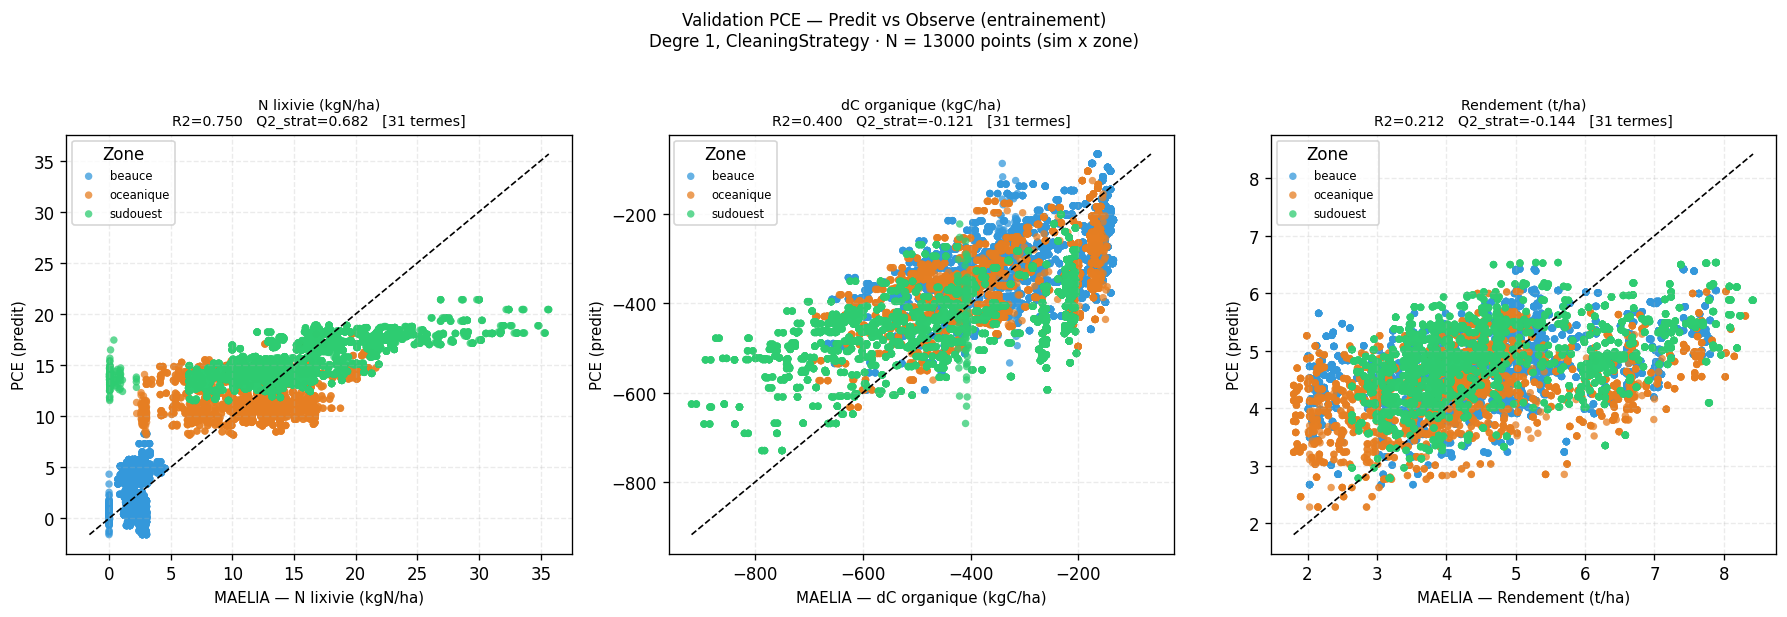

In [24]:
n_out = len([c for c in OUTPUT_COLS if c in pce_models])
fig, axes = plt.subplots(1, n_out, figsize=(5 * n_out, 5))
if n_out == 1:
    axes = [axes]

ZONE_COLORS = {0: '#3498db', 1: '#e67e22', 2: '#2ecc71'}

ax_idx = 0
for col, lbl, color in zip(OUTPUT_COLS, OUTPUT_LABELS, OUTPUT_COLORS):
    if col not in pce_models:
        continue
    ax   = axes[ax_idx]; ax_idx += 1
    k    = OUTPUT_COLS.index(col)
    mask = valid_masks[col]
    y_tr = Y_raw[mask, k]
    Y_pr = np.array(pce_models[col](ot.Sample(X_imp[mask]))).ravel()
    z_ids = ZONE_IDS[mask]
    m     = metrics.get(col, {})

    for z_id in [0, 1, 2]:
        zm = (z_ids == z_id)
        ax.scatter(y_tr[zm], Y_pr[zm], c=ZONE_COLORS[z_id], s=20,
                   alpha=0.75, edgecolors='none', label=ZONE_NAMES[z_id])

    lims = [min(y_tr.min(), Y_pr.min()), max(y_tr.max(), Y_pr.max())]
    ax.plot(lims, lims, 'k--', lw=1)
    ax.set_xlabel(f'MAELIA — {lbl}', fontsize=9)
    ax.set_ylabel('PCE (predit)', fontsize=9)
    ax.set_title(
        f'{lbl}\nR2={m.get("R2_train",0):.3f}   Q2_strat={m.get("Q2_strat",0):.3f}'
        f'   [{m.get("n_terms",0)} termes]',
        fontsize=8.5
    )
    ax.legend(fontsize=7, title='Zone', loc='upper left')
    ax.grid(alpha=0.25, linestyle='--')

fig.suptitle(
    f'Validation PCE — Predit vs Observe (entrainement)\n'
    f'Degre {PCE_DEGREE}, CleaningStrategy · N = {len(X_imp)} points (sim x zone)',
    fontsize=10, y=1.02
)
plt.tight_layout()
plt.savefig(OUT_DIR / 'pce_validation.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Indices de Sobol depuis le PCE

Les indices de Sobol **S1** (effet principal) se deduisent analytiquement des coefficients du polynome (Sudret 2008).

Avec sol_type et zone identifiables separement, on peut comparer :  
- effet **sol** (type pedo-agronomique) vs effet **zone/climat**  
- effets **pratiques agricoles** (SMT) vs effets **pedoclimatiques**  

> Pour dCorg et rdt (Q2 < 0), les indices refletent une approximation lineaire de faible qualite — les interpreter avec precaution.


In [25]:
sobol_S1 = {}
sobol_ST = {}

for col in OUTPUT_COLS:
    if col not in pce_results:
        continue
    sens = ot.FunctionalChaosSobolIndices(pce_results[col])
    sobol_S1[col] = np.array([max(0., sens.getSobolIndex(j, 0))      for j in range(N_INPUTS)])
    sobol_ST[col] = np.array([max(0., sens.getSobolTotalIndex(j, 0)) for j in range(N_INPUTS)])

print(f'  {"Variable":<44}', '  '.join(f'{c:>10}' for c in OUTPUT_COLS))
print('  ' + '-' * (44 + 14 * len(OUTPUT_COLS)))
for j, lbl in enumerate(INPUT_LABELS):
    vals = '  '.join(
        f'{sobol_S1[c][j]:10.3f}' if c in sobol_S1 else f'{"—":>10}'
        for c in OUTPUT_COLS
    )
    print(f'  {lbl:<44}  {vals}')
print(f'  {"Somme S1":<44}', '  '.join(
    f'{sobol_S1[c].sum():10.3f}' if c in sobol_S1 else '—' for c in OUTPUT_COLS
))

  Variable                                         N_lixi       dCorg         rdt
  --------------------------------------------------------------------------------------
  Nb apports fertilisation                           0.001       0.000       0.000
  Preparation sol (oui/non)                          0.001       0.002       0.001
  Nb operations prepa sol                            0.007       0.015       0.012
  Type prepa sol 1                                   0.000       0.002       0.002
  Type prepa sol 2                                   0.000       0.001       0.000
  Nb produits engrais F1                             0.000       0.003       0.002
  Type engrais F1-1                                  0.000       0.000       0.003
  Type engrais F1-2                                  0.008       0.051       0.045
  Nb produits engrais F2                             0.001       0.011       0.026
  Type engrais F2-1                                  0.000       0.001       0.000

## 9. Visualisation des indices de Sobol

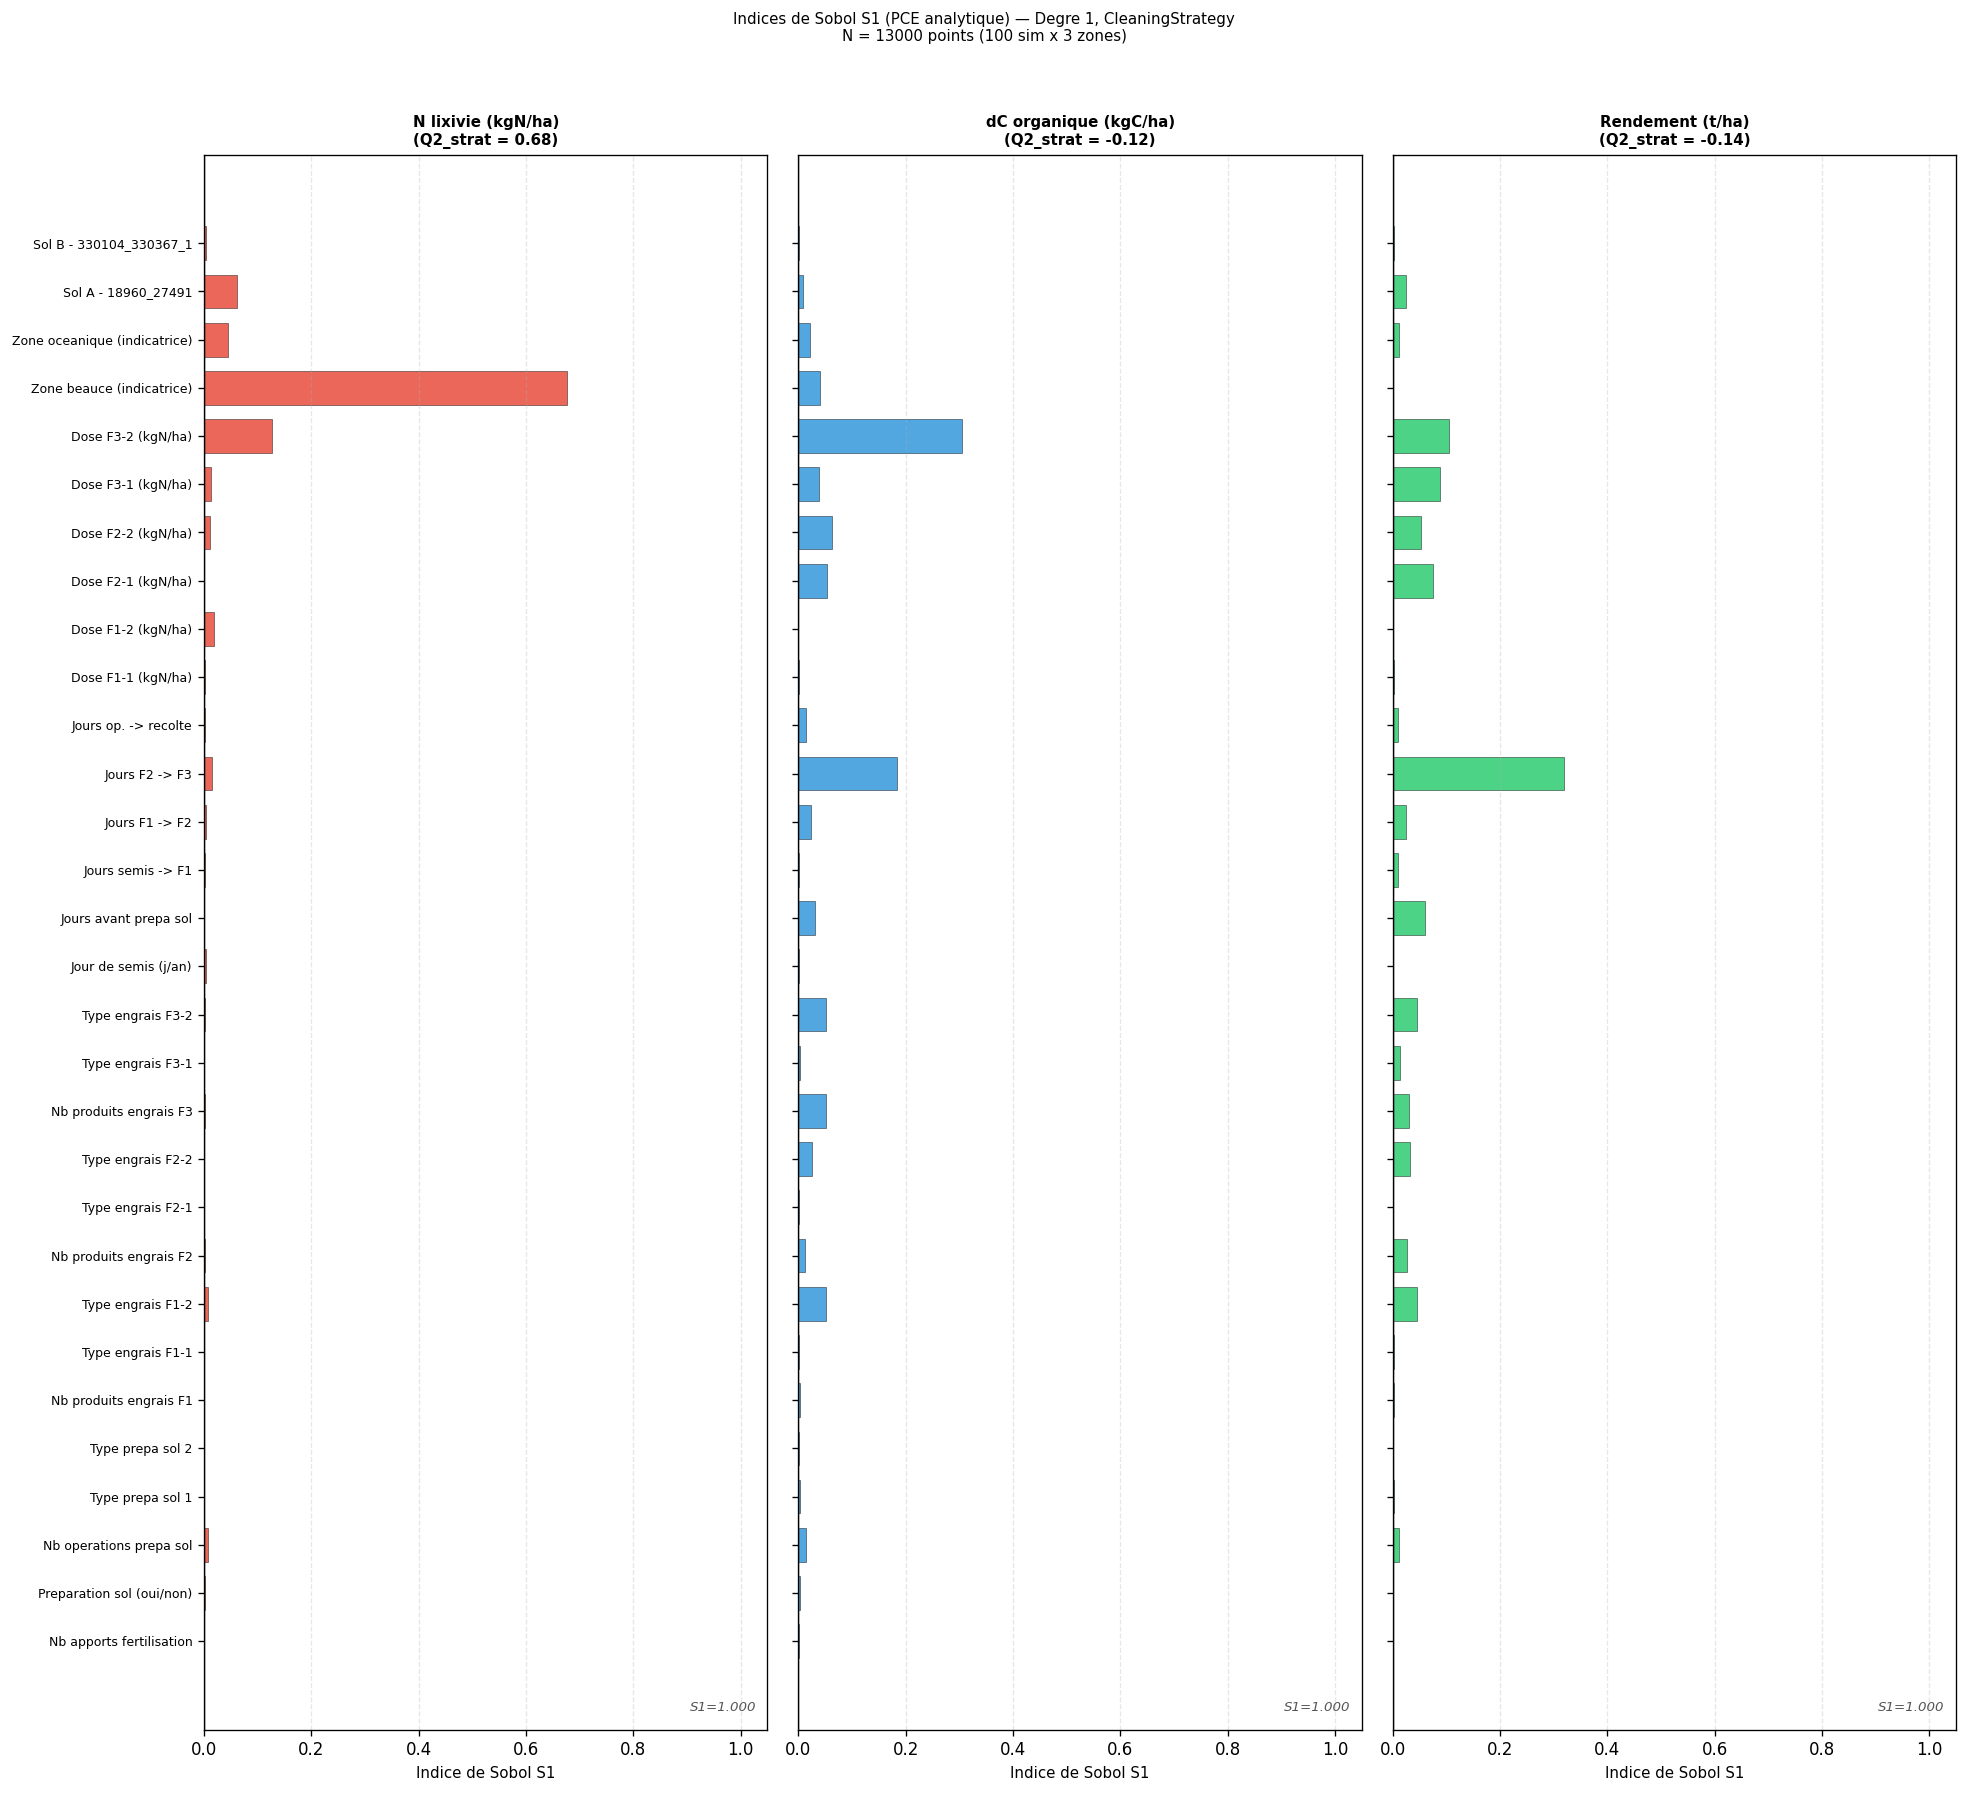

Figure -> /tmp/maelia_smt_xml/pce_sobol.png


In [26]:
n_avail = len(sobol_S1)
fig, axes = plt.subplots(
    1, n_avail,
    figsize=(5.5 * n_avail, max(8, 0.42 * N_INPUTS + 2)),
    sharey=True
)
if n_avail == 1:
    axes = [axes]

y_pos = np.arange(N_INPUTS)
ax_idx = 0
for col, lbl, color in zip(OUTPUT_COLS, OUTPUT_LABELS, OUTPUT_COLORS):
    if col not in sobol_S1:
        continue
    ax = axes[ax_idx]; ax_idx += 1
    s1 = sobol_S1[col]
    m  = metrics.get(col, {})
    q2 = m.get('Q2_strat', float('nan'))

    ax.barh(y_pos, s1, color=color, alpha=0.85, edgecolor='k',
            linewidth=0.3, height=0.7)

    ax.set_xlim(0, 1.05)
    ax.set_xlabel('Indice de Sobol S1', fontsize=9)
    q2_str = f'{q2:.2f}' if not np.isnan(q2) else 'N/A'
    ax.set_title(f'{lbl}\n(Q2_strat = {q2_str})', fontsize=9, fontweight='bold')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(INPUT_LABELS, fontsize=7.5)
    ax.axvline(0, color='k', lw=0.8)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.text(0.98, 0.01, f'S1={s1.sum():.3f}', transform=ax.transAxes,
            ha='right', va='bottom', fontsize=8, color='#555', style='italic')

fig.suptitle(
    f'Indices de Sobol S1 (PCE analytique) — Degre {PCE_DEGREE}, CleaningStrategy\n'
    f'N = {len(X_imp)} points (100 sim x 3 zones)',
    fontsize=9, y=1.02
)
plt.tight_layout()
plt.savefig(OUT_DIR / 'pce_sobol.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure -> {OUT_DIR}/pce_sobol.png')

## 10. Synthese

In [27]:
print('=' * 70)
print('SYNTHESE — METAMODELES PCE CREUX (OpenTURNS)')
print('=' * 70)
print(f'  Algorithme    : CleaningStrategy + OLS (Legendre, degre {PCE_DEGREE})')
print(f'  Entrees       : {N_INPUTS} vars (26 SMT + 2 indicatrices zone + 2 indicatrices sol_type)')
print(f'  Echantillons  : {len(X_imp)} ({N_DOE} sim x 130 parcelles)')
print(f'  CV            : {N_FOLDS_CV}-fold stratifie par simulation (n_eff = {N_DOE})')
print()
print(f'  {"Sortie":<24}  {"R2_train":>9}  {"Q2_strat":>9}  {"termes":>6}  Qualite')
print('  ' + '-' * 65)
for col, lbl in zip(OUTPUT_COLS, OUTPUT_LABELS):
    if col not in metrics:
        print(f'  {lbl:<24}  — donnees insuffisantes')
        continue
    m   = metrics[col]
    q2  = m['Q2_strat']
    qlt = 'Bon' if q2 > 0.7 else 'Acceptable' if q2 > 0.4 else 'Faible'
    print(f'  {lbl:<24}  {m["R2_train"]:9.3f}  {q2:9.3f}  {m["n_terms"]:6d}  {qlt}')
print()
print('  Top 5 variables par S1 moyen :')
if sobol_S1:
    s1_mean = np.nanmean([sobol_S1[c] for c in OUTPUT_COLS if c in sobol_S1], axis=0)
    for rank, j in enumerate(np.argsort(s1_mean)[::-1][:5]):
        print(f'    {rank+1}. {INPUT_LABELS[j]:<44}  S1_moy = {s1_mean[j]:.3f}')
print()
print('  Recommandation : N_DOE >= 300 pour ameliorer la qualite de dCorg et rdt.')
print('=' * 70)


SYNTHESE — METAMODELES PCE CREUX (OpenTURNS)
  Algorithme    : CleaningStrategy + OLS (Legendre, degre 1)
  Entrees       : 30 vars (26 SMT + 2 indicatrices zone + 2 indicatrices sol_type)
  Echantillons  : 13000 (100 sim x 130 parcelles)
  CV            : 5-fold stratifie par simulation (n_eff = 100)

  Sortie                     R2_train   Q2_strat  termes  Qualite
  -----------------------------------------------------------------
  N lixivie (kgN/ha)            0.750      0.682      31  Acceptable
  dC organique (kgC/ha)         0.400     -0.121      31  Faible
  Rendement (t/ha)              0.212     -0.144      31  Faible

  Top 5 variables par S1 moyen :
    1. Zone beauce (indicatrice)                     S1_moy = 0.239
    2. Dose F3-2 (kgN/ha)                            S1_moy = 0.178
    3. Jours F2 -> F3                                S1_moy = 0.173
    4. Dose F3-1 (kgN/ha)                            S1_moy = 0.046
    5. Dose F2-1 (kgN/ha)                            S1_m